
## Using Fast Moving Consumer Goods (FMCG) Companies for Analysis

## Data Loading and Cleaning

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Loading the dataset
df = pd.read_csv('50 FMCG Companies.csv')

In [ ]:
# setting the company name as index
df.set_index('Name', inplace=True)

In [ ]:
# checking for missing values
df.isnull().sum()

,0
S.No.,0
CMP Rs.,0
P/E,2
Mar Cap Rs.Cr.,0
Div Yld%,0
NP QtrRs.Cr.,0
Qtr Profit Var%,1
Sales QtrRs.Cr.,0
Qtr Sales Var%,1
ROCE%,2


In [ ]:
# filling the missing values with median
# median is preferred over mean because it is robust to outliers

df.fillna(df.median(numeric_only=True), inplace=True)

## Company's Performance using EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# selecting only the financial ratio columns for analysis
financial_cols = ['P/E', 'Div Yld%', 'NP QtrRs.Cr.', 'Qtr Profit Var%',
                  'Sales QtrRs.Cr.', 'Qtr Sales Var%', 'ROCE%', 'PAT 12MRs.Cr.',
                  'ROE%', 'ROA 12M%', 'Current ratio', 'Quick Rat',
                  'Debt / Eq', 'Int Coverage']

df_financial = df[financial_cols]

# Getting the Summary statistics of the selected columns
# to have a sense of the spread and scale of each ratio
df_financial.describe()

,P/E,Div Yld%,NP QtrRs.Cr.,Qtr Profit Var%,Sales QtrRs.Cr.,Qtr Sales Var%,ROCE%,PAT 12MRs.Cr.,ROE%,ROA 12M%,Current ratio,Quick Rat,Debt / Eq,Int Coverage
count,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000
mean,45.016600,0.779800,425.57700,37.119000,3288.159200,54.715000,26.365000,1346.16460,22.315400,12.50540,4.131400,3.399400,0.274400,53.038400
std,27.867608,0.880057,1146.00167,140.110084,4504.045163,245.961141,21.332975,3229.30261,17.308919,8.58392,13.922933,14.000623,0.320848,100.571022
min,9.600000,0.000000,-178.38000,-643.120000,104.400000,-12.670000,6.160000,-578.30000,-1.010000,-3.08000,0.370000,0.120000,0.000000,0.160000
25%,25.705000,0.130000,63.63500,9.980000,833.732500,7.732500,13.995000,251.70500,12.267500,6.40250,1.345000,0.672500,0.040000,7.102500
50%,39.460000,0.625000,106.65000,19.510000,1481.155000,13.980000,19.975000,434.04500,17.050000,10.40000,1.905000,1.060000,0.140000,15.920000
75%,57.422500,1.267500,338.43250,63.240000,3660.162500,22.442500,28.105000,1244.46750,26.540000,15.80500,2.512500,1.750000,0.397500,45.845000
max,181.970000,4.760000,6603.00000,676.390000,20047.300000,1750.040000,105.340000,20630.00000,81.190000,46.23000,100.000000,100.000000,1.190000,443.350000


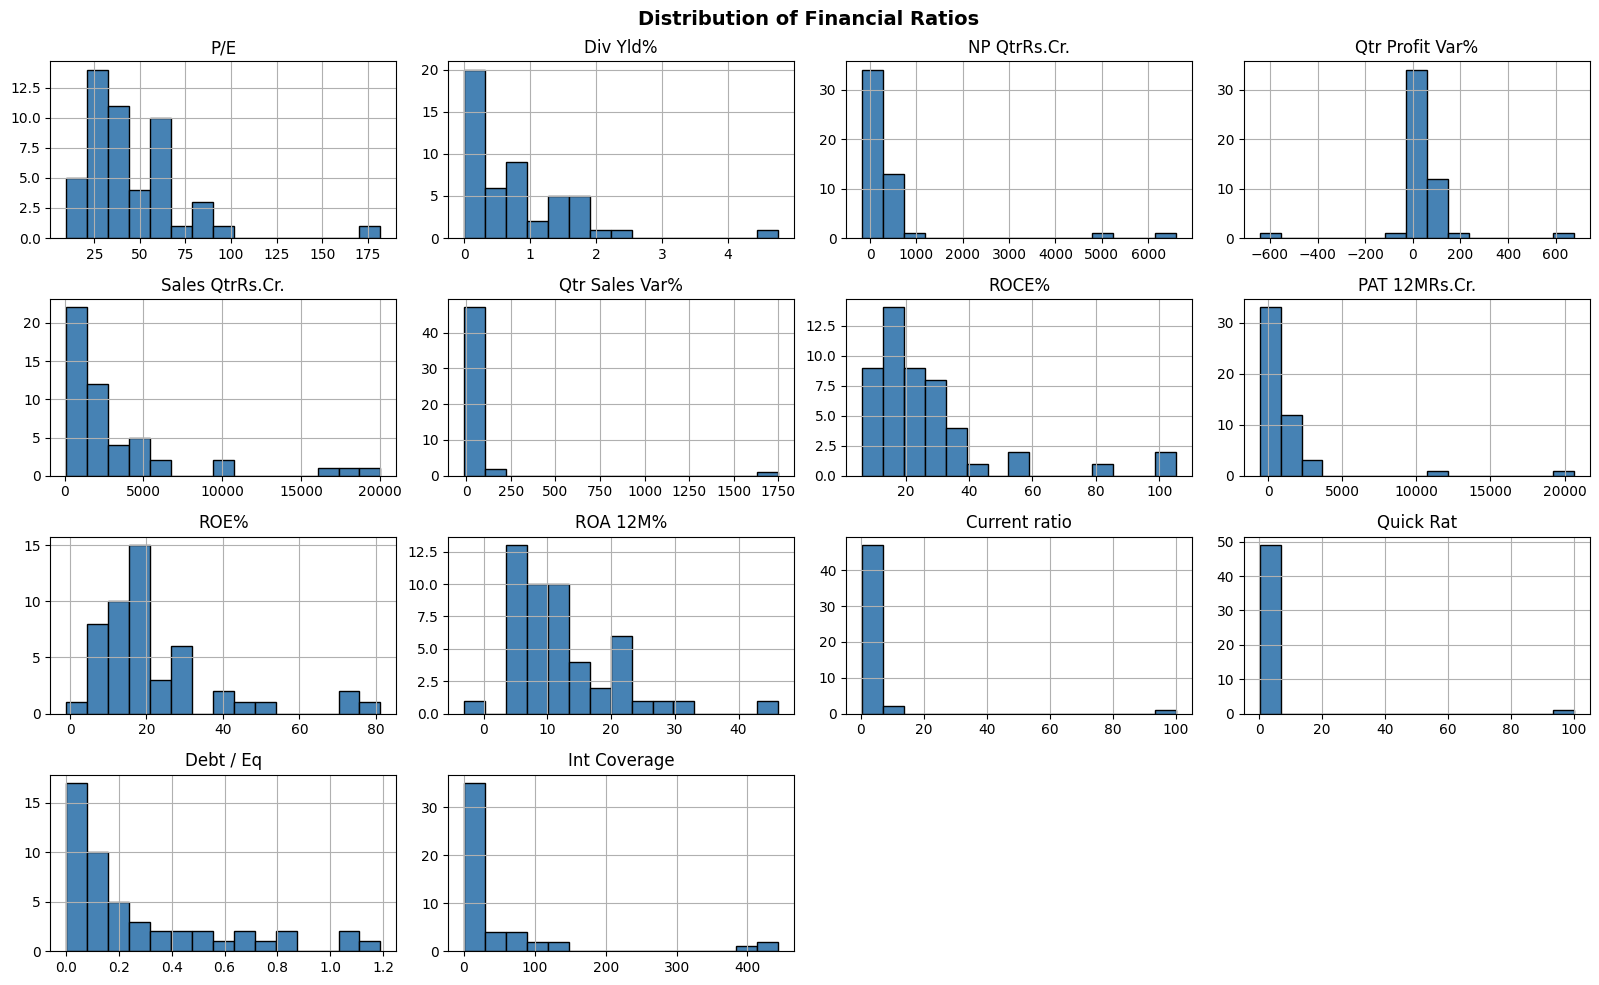

In [ ]:
# Plotting the distribution of each financial ratio
# to help identify the skewness and the outliers visually
df_financial.hist(figsize=(16, 10), bins=15, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Financial Ratios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

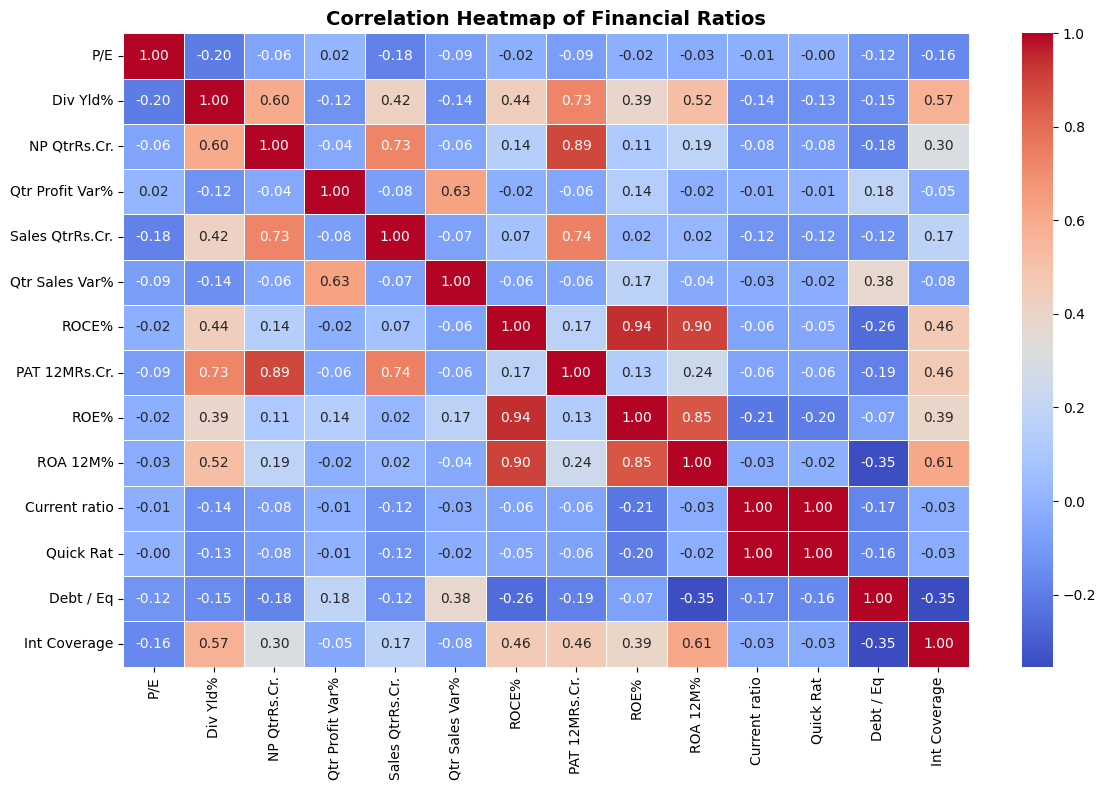

In [ ]:
# Plotting the correlation heatmap to show which ratios move together
plt.figure(figsize=(12, 8))
sns.heatmap(df_financial.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Financial Ratios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Pre-Processing and Scaling the Dataset


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# We'll select only financial ratio columns for clustering
# Dropping the absolute value columns NP_Qtr, Sales_Qtr, PAT_12M as they show company size rather than financial properties
# Ratios are more useful for clustering

cluster_cols = ['P/E', 'Div Yld%', 'Qtr Profit Var%', 'Qtr Sales Var%',
                'ROCE%', 'ROE%', 'ROA 12M%', 'Current ratio',
                'Quick Rat', 'Debt / Eq', 'Int Coverage']

df_cluster = df[cluster_cols]

In [ ]:
# Next we standardize the data using StandardScalar
# Clustering methods like K-means are distance based, so larger scales dominate over smaller ones
# Scaling it brings all the features to the same scale.

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# Converting back to DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=cluster_cols, index=df_cluster.index)

df_scaled.head()

,P/E,Div Yld%,Qtr Profit Var%,Qtr Sales Var%,ROCE%,ROE%,ROA 12M%,Current ratio,Quick Rat,Debt / Eq,Int Coverage
Name,,,,,,,,,,,
Hind. Unilever,0.184627,1.228404,-0.198260,-0.201344,0.070317,-0.093108,0.080563,-0.220663,-0.183941,-0.737981,-0.189317
ITC,-0.968068,4.568579,-0.198260,-0.197237,0.493641,0.292070,1.136150,-0.079184,-0.112512,-0.832432,3.675680
Nestle India,1.247426,0.195360,-0.059689,-0.131895,2.739059,2.971971,1.691598,-0.230095,-0.214965,-0.612046,-0.237930
Varun Beverages,0.414803,-0.539249,-0.008140,-0.167297,-0.315126,-0.356313,-0.040647,-0.158993,-0.157966,-0.454626,-0.321498
Britannia Inds.,0.440177,0.608578,-0.145845,-0.190994,1.260739,1.787259,1.413874,-0.231546,-0.209915,0.993629,-0.260530


## K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

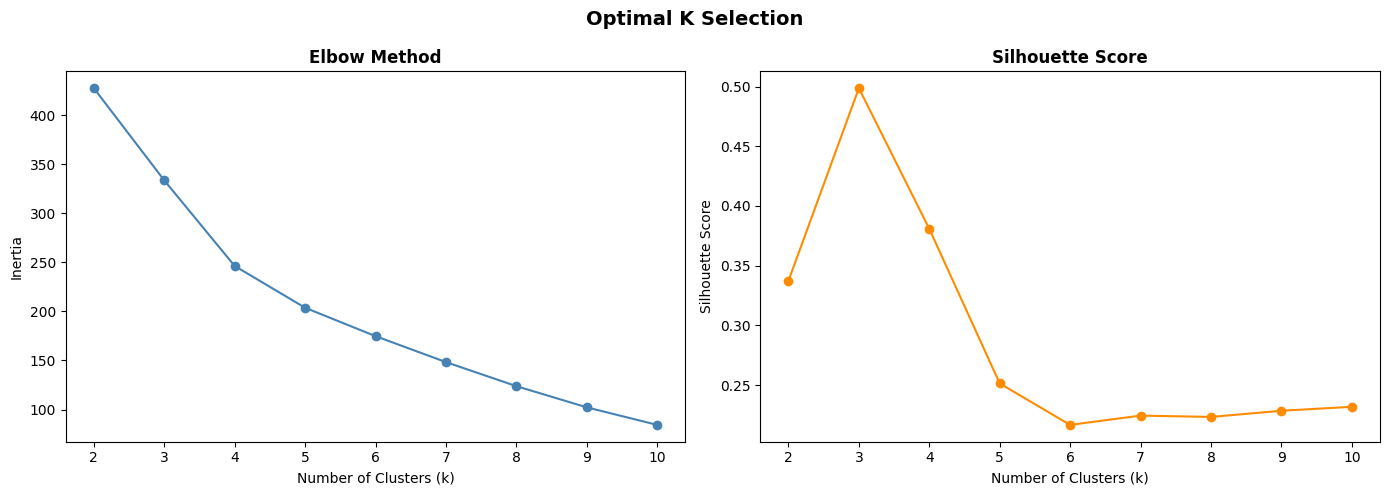

In [ ]:
# Plotting the Elbow Curve and the Silhoutte score
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Creating a KMeans model with k clusters
    kmeans.fit(df_scaled) # fitting the model on a scaled data
    # Calculating the inertia which is sum of the squared distances of each point to it's nearest cluster centre
    inertia.append(kmeans.inertia_)
    # Lower the inertia, tighter and more compact is the cluster
    # Calculating the Silhoutte score to measure how well each point fits it's own cluster vs other clusters
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Plotting Elbow Curve and Silhouette Score side by side for easy reference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plotting Elbow Curve
axes[0].plot(k_range, inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

# Plotting Silhouette Score
axes[1].plot(k_range, silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Fitting K-means with optimal K
# Based on the above Elbow plot and Silhoutte scores, we pick the optimal K which is 3
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# See how many companies fall in each cluster
print(df['Cluster'].value_counts())


Cluster
1    45
2     4
0     1
Name: count, dtype: int64


In [ ]:
# Visualizing the clusters
from sklearn.decomposition import PCA

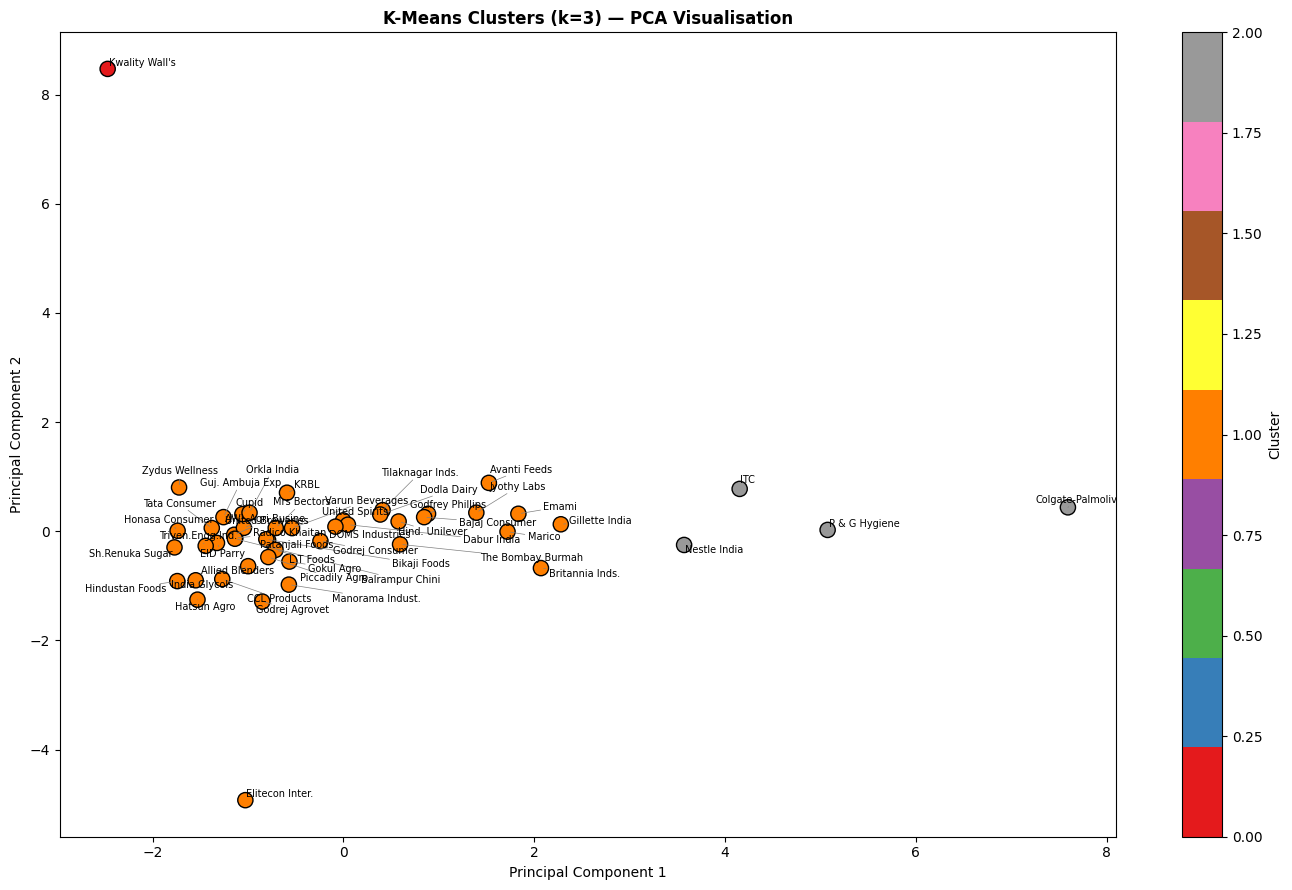

In [ ]:
# Since we have only used 11 columns for clustering, we use PCA to reduce to 2 dimensions
# PCA helps to find the two directions of maximum variance in the data
!pip install adjustText
from sklearn.decomposition import PCA
from adjustText import adjust_text

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(df_scaled)

plt.figure(figsize=(14, 9))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1],
                      c=df['Cluster'], cmap='Set1', s=120, edgecolors='black')

# Use adjustText to automatically push labels apart so they don't overlap
texts = []
for i, name in enumerate(df.index):
    texts.append(plt.text(pca_coords[i, 0], pca_coords[i, 1], name, fontsize=7))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title(f'K-Means Clusters (k={optimal_k}) — PCA Visualisation', fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## Feature Ranking

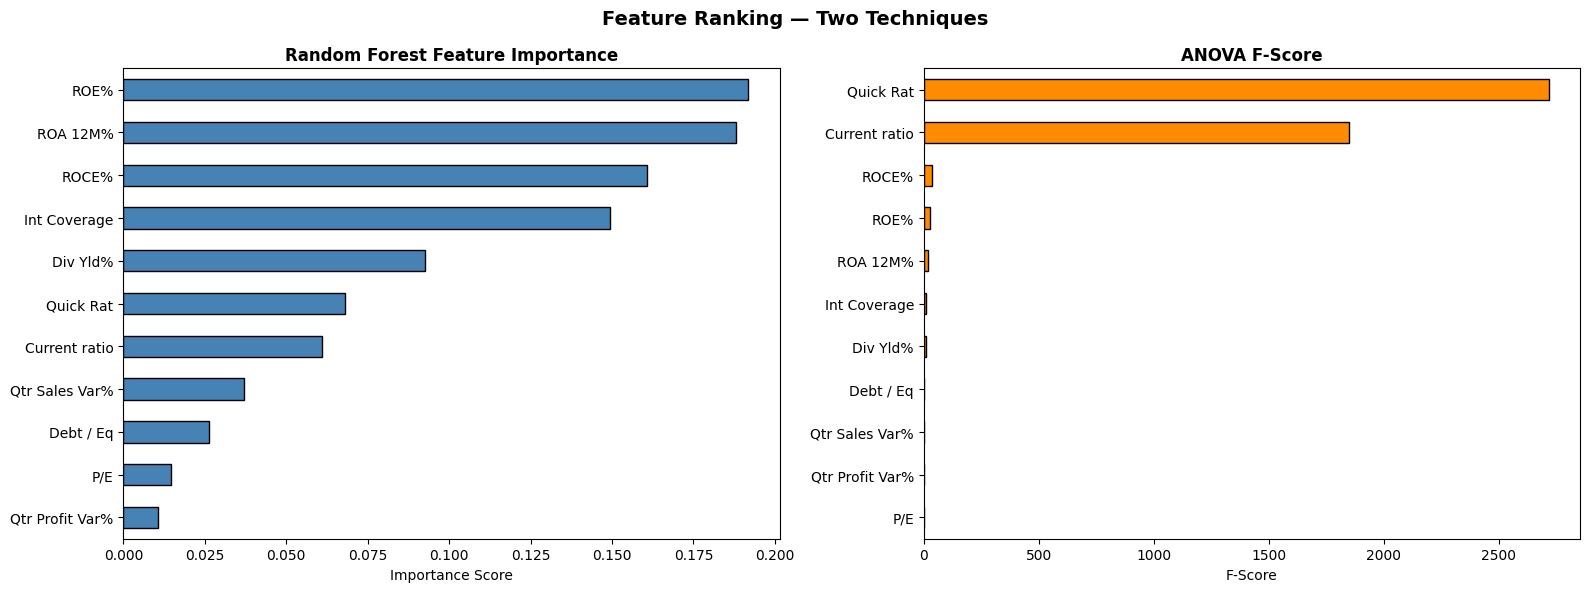

In [ ]:
from sklearn.feature_selection import f_classif
from sklearn.ensemble import RandomForestClassifier

# Technique 1: We rank features using F-scores
# Highwer the F-score, feature varies more between clusters and higher it is useful of separation
f_scores, _ = f_classif(df_scaled, df['Cluster'])
fscore_importance = pd.Series(f_scores, index=cluster_cols).sort_values(ascending=False)

# Technique 2: We rank features using Random Forest feature Importance
# In this method, features that help separate clusters better will have higher importance score
rff = RandomForestClassifier(n_estimators=100, random_state=42)
rff.fit(df_scaled, df['Cluster'])

rff_importance = pd.Series(rff.feature_importances_, index=cluster_cols).sort_values(ascending=False)

# Plotting both the techniques side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rff_importance.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Random Forest Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

fscore_importance.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('ANOVA F-Score', fontweight='bold')
axes[1].set_xlabel('F-Score')
axes[1].invert_yaxis()

plt.suptitle('Feature Ranking — Two Techniques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Agglomerative Clustering and Dendrograms


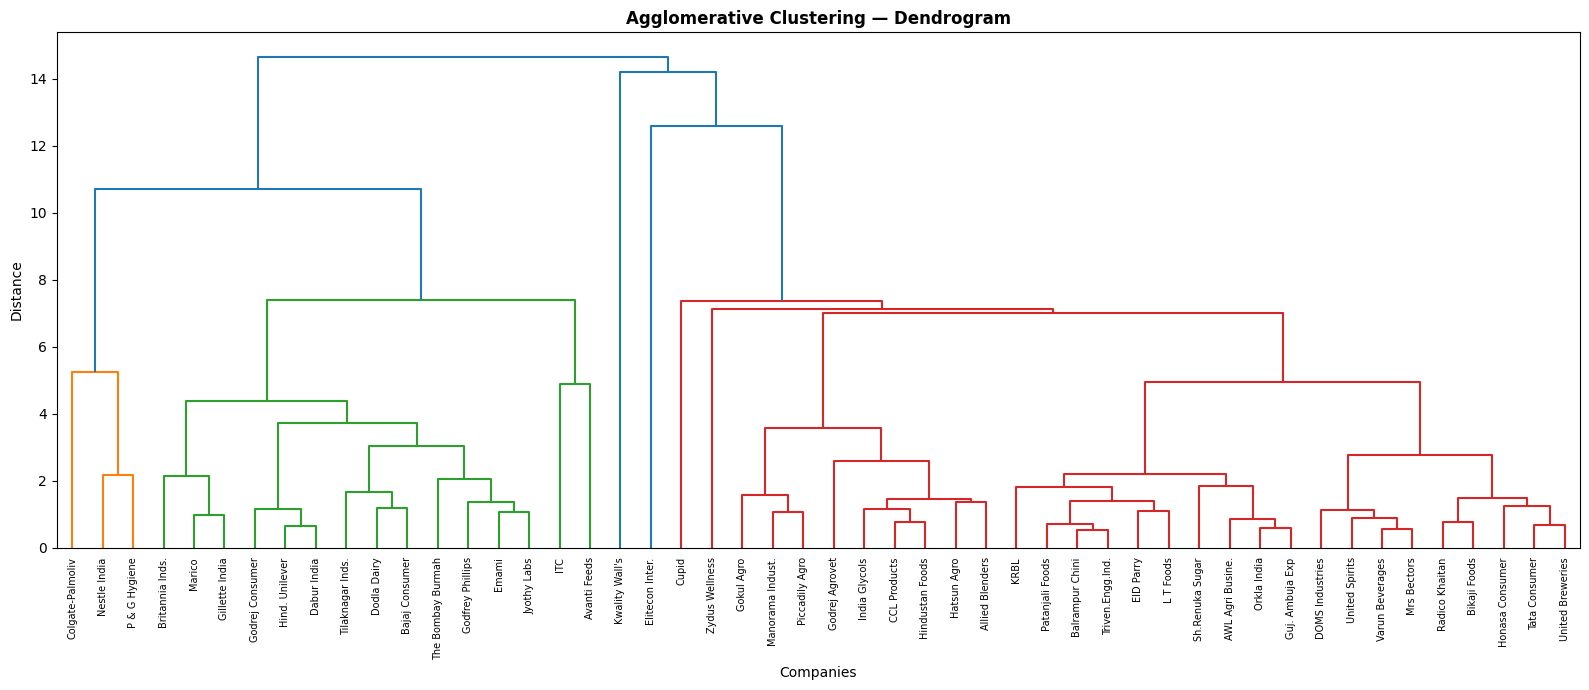

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# We compute Linkage matrices to minimise the variance within clusters using wards
linkage_matrix = linkage(df_scaled, method='ward')

# Plotting the Dendrogram using the Linkage Matrix
plt.figure(figsize=(16, 7))
dendrogram(
    linkage_matrix,
    labels=df.index.tolist(),  # we get company names on x-axis
    leaf_rotation=90,           # we rotate labels for readability
    leaf_font_size=7
)
plt.title('Agglomerative Clustering — Dendrogram', fontweight='bold')
plt.xlabel('Companies')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# While calculating K-mmeans, we have used the optimal k=3
# We use the samw optimal k here for comparison and consistency
agglomeraive = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Agglomerative_Cluster'] = agglomeraive.fit_predict(df_scaled)

# Let's compare Agglomerative and K-means Clustering
print(pd.crosstab(df['Cluster'], df['Agglomerative_Cluster'],
                  rownames=['K-Means'], colnames=['Agglomerative']))

Agglomerative   0   1  2
K-Means                 
0               0   0  1
1              31  14  0
2               0   4  0


## Outlier Detection

In [ ]:
from sklearn.ensemble import IsolationForest

# We use Isolation Forest technique which is highly useful in outlier detection
# Outliers are easier to isolate as it isolates the anomalies by randomly partitioning the data
# and so, they have shorter paths in the tree
isolation_forest = IsolationForest(contamination=0.05, random_state=42) # Contamination means expected proportion of outliers (5%)
df['Outlier'] = isolation_forest.fit_predict(df_scaled)
# fit_predict returns: 1 = normal, -1 = outlier
outliers = df[df['Outlier'] == -1]
print(f"Number of outliers detected: {len(outliers)}")
print("\nOutlier companies:")
print(outliers.index.tolist())

Number of outliers detected: 3

Outlier companies:
['Colgate-Palmoliv', "Kwality Wall's", 'Elitecon Inter.']


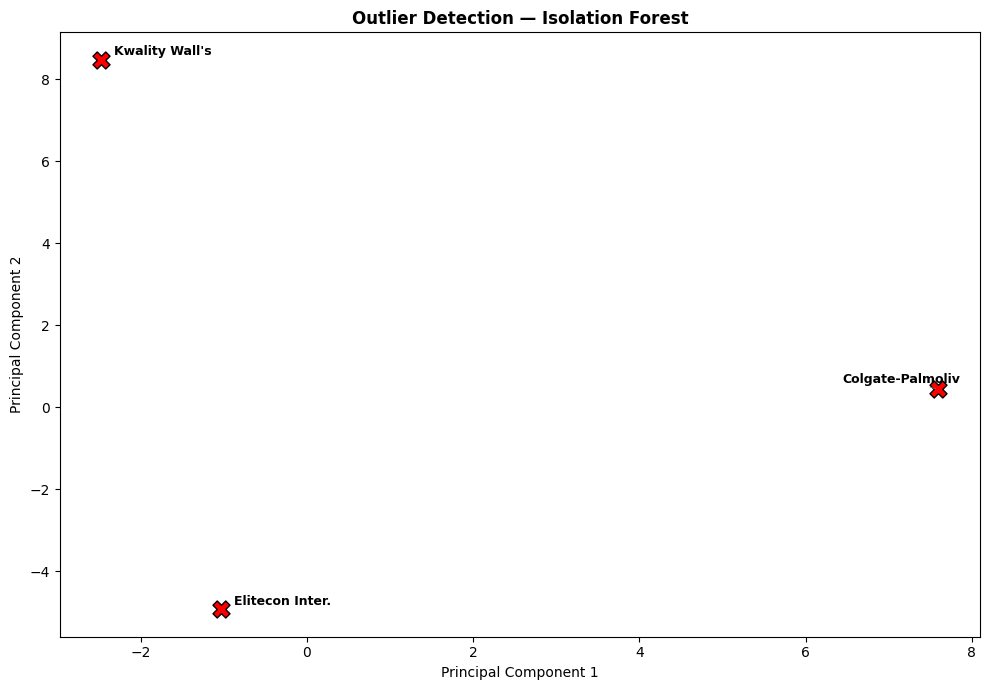

In [ ]:
# visualizing the outliers on a PCA plot
pca_coords_df = pd.DataFrame(pca_coords, index=df.index, columns=['PC1', 'PC2'])
pca_coords_df['Outlier'] = df['Outlier']

outlier = pca_coords_df[pca_coords_df['Outlier'] == -1]

plt.figure(figsize=(10, 7))
plt.scatter(outlier['PC1'], outlier['PC2'], c='red', s=150,
            edgecolors='black', marker='X', label='Outlier')

# Labelling each outlier company
names = []
for companyname in outlier.index:
    names.append(plt.text(outlier['PC1'][companyname], outlier['PC2'][companyname],
                          companyname, fontsize=9, fontweight='bold'))

adjust_text(names, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title('Outlier Detection — Isolation Forest', fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()